# wind_geo sweep — comprehensive analysis

Geostrophic wind sweep (realistic Ekman shear via `swlspres=geo`).
All runs: aerosols off.

| Key | u_g (m s⁻¹) | Note |
|-----|------------|------|
| `wind_geo_0`    | 0   | reference (no_aerosols_zero_wind) |
| `wind_geo_2p5`  | 2.5 | |
| `wind_geo_5p0`  | 5   | |
| `wind_geo_7p5`  | 7.5 | |
| `wind_geo_10p0` | 10  | |

**Sections**
1. LWP overview
2. Thermodynamic structure
3. Surface energy balance


In [1]:
import os, sys, pickle, warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from cass_analysis import (
    load_stats, load_stats_ensemble,
    lwp_integral,
    RunSet, _to_plottime,
    rho, cp, Lv,
    LST_OFFSET,
)
from catalog import make_runset, list_group, CASS_ROOT, ALL_EXPERIMENTS


In [2]:
COMPOSITE_ROOT = CASS_ROOT / "analysis/cloud_root_composite"
N_REPS         = 4
LST_OFF        = LST_OFFSET   # from cass_analysis (5.5 h)
LST_MIN_H, LST_MAX_H = 12.5, 19.0

SWEEP_GROUP = "wind_geo"
_all_sweep  = list_group(SWEEP_GROUP)
sweep = _all_sweep

PARAM_UNIT = "m s$^{-1}$"

# ── colour / style: colour per param value, solid=2stream, dashed=raytracer ─
COLORS  = {key: meta["color"]  for key, meta in sweep}
LABELS  = {key: meta["label"]  for key, meta in sweep}
PARAMS  = {key: meta["param"]  for key, meta in sweep}

def lst_mask(s, lo=LST_MIN_H, hi=LST_MAX_H):
    t_local = s["t_local"].values if hasattr(s, "data_vars") else (s["t_local"] if isinstance(s, dict) else s)
    import pandas as _pd
    hours = _pd.DatetimeIndex(t_local).hour + _pd.DatetimeIndex(t_local).minute / 60
    return (hours >= lo) & (hours <= hi)

def axvspan_window(ax, t_local, mask, **kwargs):
    t_num = _to_plottime(t_local)
    valid = t_num[mask]
    if len(valid):
        ax.axvspan(valid[0], valid[-1], **kwargs)

# ── PDF output switch ────────────────────────────────────────────────────────
SAVE_PDF = False   # set True to write .pdf files

def _savefig(fname, **kwargs):
    if SAVE_PDF:
        plt.savefig(fname, **kwargs)


---
## Data loading

In [3]:
data = {}  # key -> dict with all loaded arrays

for key, meta in sweep:
    rs = make_runset(key, n_reps=N_REPS)
    dirs_2s = rs.dirs.get("2stream",   [])
    dirs_rt = rs.dirs.get("raytracer", [])

    if not dirs_2s:
        print(f"  {key}: no 2stream reps found, skipping")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        reps_2s = [load_stats(d) for d in dirs_2s]
        reps_rt = [load_stats(d) for d in dirs_rt] if dirs_rt else []

    # ── Ensemble means ──────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        s2s_mean, s2s_std = load_stats_ensemble(dirs_2s)
        srt_mean, srt_std = (load_stats_ensemble(dirs_rt)
                              if dirs_rt else (None, None))

    # ── LWP per-rep (for σ across reps) ────────────────────────────────────
    nt_lwp  = min(s["qlqi_path"].sizes["time"] for s in reps_2s)
    if reps_rt:
        nt_lwp = min(nt_lwp, *(s["qlqi_path"].sizes["time"] for s in reps_rt))
    n_paired = min(len(reps_2s), len(reps_rt)) if reps_rt else len(reps_2s)

    lwp_1d_reps = np.stack([s["qlqi_path"].values[:nt_lwp] * 1e3 for s in reps_2s[:n_paired]])
    lwp_1d      = lwp_1d_reps.mean(axis=0)
    lwp_1d_std  = lwp_1d_reps.std(axis=0)

    if reps_rt:
        lwp_rt_reps = np.stack([s["qlqi_path"].values[:nt_lwp] * 1e3 for s in reps_rt[:n_paired]])
        lwp_rt      = lwp_rt_reps.mean(axis=0)
        lwp_rt_std  = lwp_rt_reps.std(axis=0)
        diff_reps   = lwp_rt_reps - lwp_1d_reps
        diff        = diff_reps.mean(axis=0)
        diff_std    = diff_reps.std(axis=0)
    else:
        lwp_rt = lwp_rt_std = diff = diff_std = diff_reps = None

    t_local_lwp = reps_2s[0]["t_local"].values[:nt_lwp]
    t_sec_lwp   = reps_2s[0]["t_sec"].values[:nt_lwp]
    dt_s        = float(t_sec_lwp[1] - t_sec_lwp[0]) if len(t_sec_lwp) > 1 else 60.0
    t_num_lwp   = _to_plottime(t_local_lwp)

    if diff is not None:
        cloudy_mask = (lwp_1d > 0.1) | (lwp_rt > 0.1)
        int_diff    = lwp_integral(diff, dt_s, cloudy_mask=cloudy_mask)
        int_1d      = lwp_integral(lwp_1d, dt_s, cloudy_mask=cloudy_mask)
        norm_int    = int_diff / int_1d * 100 if abs(int_1d) > 1e-6 else np.nan
        norm_int_std = float(np.std(
            [lwp_integral(diff_reps[r], dt_s, cloudy_mask=cloudy_mask) / int_1d * 100
             for r in range(n_paired)], ddof=0)) if abs(int_1d) > 1e-6 else np.nan
    else:
        norm_int = norm_int_std = None

    data[key] = dict(
        dirs_2s=dirs_2s, dirs_rt=dirs_rt,
        reps_2s=reps_2s, reps_rt=reps_rt,
        n_paired=n_paired,
        s2s_mean=s2s_mean, s2s_std=s2s_std,
        srt_mean=srt_mean, srt_std=srt_std,
        lwp_1d=lwp_1d, lwp_1d_std=lwp_1d_std,
        lwp_rt=lwp_rt, lwp_rt_std=lwp_rt_std,
        diff=diff, diff_std=diff_std,
        norm_int=norm_int, norm_int_std=norm_int_std,
        t_local_lwp=t_local_lwp, t_num_lwp=t_num_lwp, dt_s=dt_s,
    )
    print(f"  {key:25s}  2s={len(dirs_2s)}  rt={len(dirs_rt)}  "
          f"norm_int={norm_int:+.1f}%" if norm_int is not None
          else f"  {key:25s}  2s={len(dirs_2s)}  rt=0 (no raytracer)")

available = [k for k in data]
print(f"\nLoaded {len(available)} sweep values: {available}")


  wind_geo_0                 2s=4  rt=4  norm_int=+45.7%
  wind_geo_2p5               2s=4  rt=4  norm_int=+37.1%
  wind_geo_5p0               2s=4  rt=4  norm_int=+27.3%
  wind_geo_7p5               2s=4  rt=4  norm_int=+23.4%
  wind_geo_10p0              2s=4  rt=4  norm_int=+18.1%

Loaded 5 sweep values: ['wind_geo_0', 'wind_geo_2p5', 'wind_geo_5p0', 'wind_geo_7p5', 'wind_geo_10p0']


---
## 1. LWP overview

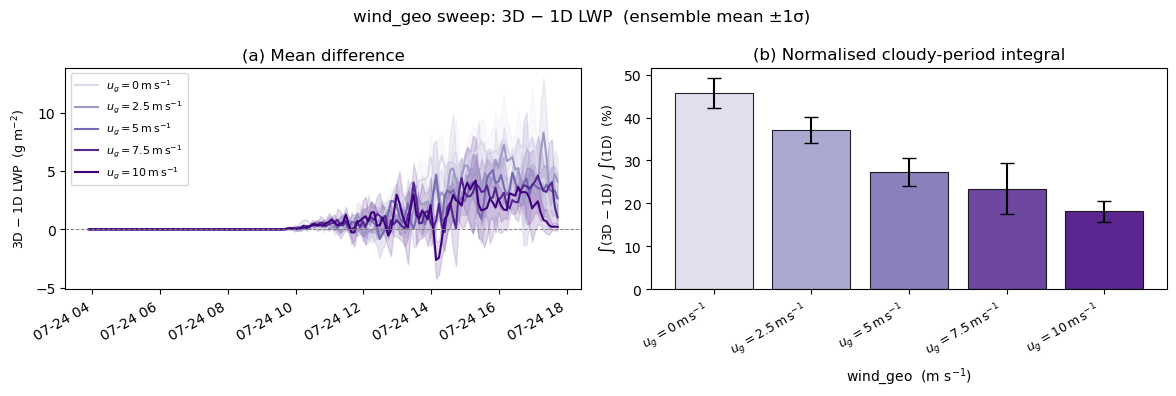

In [4]:
# ── LWP summary: mean difference + cloudy-period integral ────────────────────
keys_d = [k for k in available if data[k]["diff"] is not None]

fig, (ax_diff, ax_int) = plt.subplots(1, 2, figsize=(12, 4))

for key in keys_d:
    d   = data[key]
    c   = COLORS[key]
    lbl = LABELS[key]
    ax_diff.plot(d["t_num_lwp"], d["diff"], color=c, lw=1.5, label=lbl)
    ax_diff.fill_between(d["t_num_lwp"],
                         d["diff"] - d["diff_std"],
                         d["diff"] + d["diff_std"], color=c, alpha=0.15)

ax_diff.axhline(0, color="gray", lw=0.7, ls="--")
ax_diff.set_ylabel(r"3D − 1D LWP  (g m$^{-2}$)", fontsize=9)
ax_diff.set_title("(a) Mean difference")
ax_diff.legend(fontsize=8)
ax_diff.xaxis_date()

norm_ints = [data[k]["norm_int"] for k in keys_d]
norm_stds = [data[k]["norm_int_std"] for k in keys_d]
colors_v  = [COLORS[k]              for k in keys_d]
x = np.arange(len(keys_d))
ax_int.bar(x, norm_ints, color=colors_v, edgecolor="k", lw=0.8, alpha=0.85,
           yerr=norm_stds, capsize=5, error_kw=dict(lw=1.5))
ax_int.axhline(0, color="gray", lw=0.7)
ax_int.set_xticks(x)
ax_int.set_xticklabels([LABELS[k] for k in keys_d], rotation=15, ha="right", fontsize=9)
ax_int.set_xlabel(f"{SWEEP_GROUP}  ({PARAM_UNIT})")
ax_int.set_ylabel(r"$\int$(3D $-$ 1D) / $\int$(1D)  (%)", fontsize=9)
ax_int.set_title("(b) Normalised cloudy-period integral")

ax_diff.figure.autofmt_xdate()

fig.suptitle(f"{SWEEP_GROUP} sweep: 3D − 1D LWP  (ensemble mean ±1σ)", fontsize=12)
plt.tight_layout()
_savefig(f"{SWEEP_GROUP}_lwp_summary.pdf", bbox_inches="tight")
plt.show()


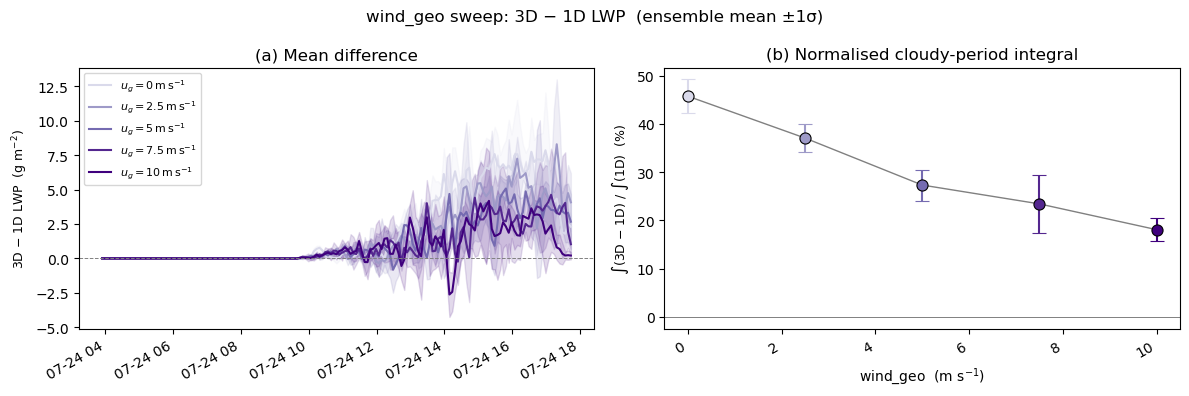

In [5]:
# ── LWP summary: mean difference + cloudy-period integral ────────────────────
import re
keys_d = [k for k in available if data[k]["diff"] is not None]

def _xnum(k):
    return float(k.split("_")[-1].replace("p", "."))   # "wind_geo_2p5" -> 2.5

xval  = {k: _xnum(k) for k in keys_d}
order = sorted(keys_d, key=lambda k: xval[k])

fig, (ax_diff, ax_int) = plt.subplots(1, 2, figsize=(12, 4))

for key in keys_d:
    d   = data[key]
    c   = COLORS[key]
    lbl = LABELS[key]
    ax_diff.plot(d["t_num_lwp"], d["diff"], color=c, lw=1.5, label=lbl)
    ax_diff.fill_between(d["t_num_lwp"],
                         d["diff"] - d["diff_std"],
                         d["diff"] + d["diff_std"], color=c, alpha=0.15)

ax_diff.axhline(0, color="gray", lw=0.7, ls="--")
ax_diff.set_ylabel(r"3D − 1D LWP  (g m$^{-2}$)", fontsize=9)
ax_diff.set_title("(a) Mean difference")
ax_diff.legend(fontsize=8)
ax_diff.xaxis_date()

# panel (b): scatter + connecting line vs wind_geo
ax_int.plot([xval[k] for k in order],
            [data[k]["norm_int"] for k in order],
            "-", color="gray", lw=1.0, zorder=1)
for key in order:
    ax_int.errorbar(xval[key], data[key]["norm_int"],
                    yerr=data[key]["norm_int_std"],
                    fmt="o", ms=8, color=COLORS[key], ecolor=COLORS[key],
                    mec="k", mew=0.8, capsize=5, lw=1.5,
                    label=LABELS[key], zorder=2)
ax_int.axhline(0, color="gray", lw=0.7)
ax_int.set_xlabel(f"{SWEEP_GROUP}  ({PARAM_UNIT})")
ax_int.set_ylabel(r"$\int$(3D $-$ 1D) / $\int$(1D)  (%)", fontsize=9)
ax_int.set_title("(b) Normalised cloudy-period integral")


ax_diff.figure.autofmt_xdate()

fig.suptitle(f"{SWEEP_GROUP} sweep: 3D − 1D LWP  (ensemble mean ±1σ)", fontsize=12)
plt.tight_layout()
_savefig(f"{SWEEP_GROUP}_lwp_summary.pdf", bbox_inches="tight")
plt.show()


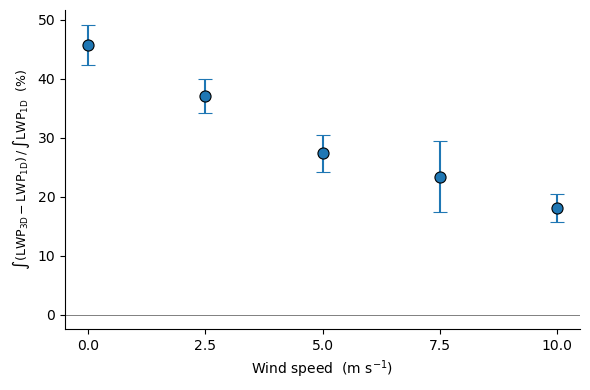

In [6]:
def _xnum(k):
    return float(k.split("_")[-1].replace("p", "."))   # wind_geo_2p5 -> 2.5
order = sorted(keys_d, key=_xnum)
xs = [_xnum(k) for k in order]

fig, ax_int = plt.subplots(figsize=(6, 4))
ax_int.errorbar(xs, [data[k]["norm_int"] for k in order],
                yerr=[data[k]["norm_int_std"] for k in order],
                fmt="o", ms=8, color="C0", ecolor="C0",
                mec="k", mew=0.8, capsize=5, lw=1.5, zorder=2)
ax_int.axhline(0, color="gray", lw=0.7)

ax_int.set_xticks(xs)
ax_int.set_xlabel(r"Wind speed  (m s$^{-1}$)")
ax_int.set_ylabel(r"$\int(\mathrm{LWP_{3D}} - \mathrm{LWP_{1D}})\,/\,\int \mathrm{LWP_{1D}}$  (%)", fontsize=9)

ax_int.spines[["top", "right"]].set_visible(False)   # sns.despine() equivalent
plt.tight_layout()
_savefig(f"{SWEEP_GROUP}_norm_int.pdf", bbox_inches="tight")
plt.show()



---
## 2. Thermodynamic structure

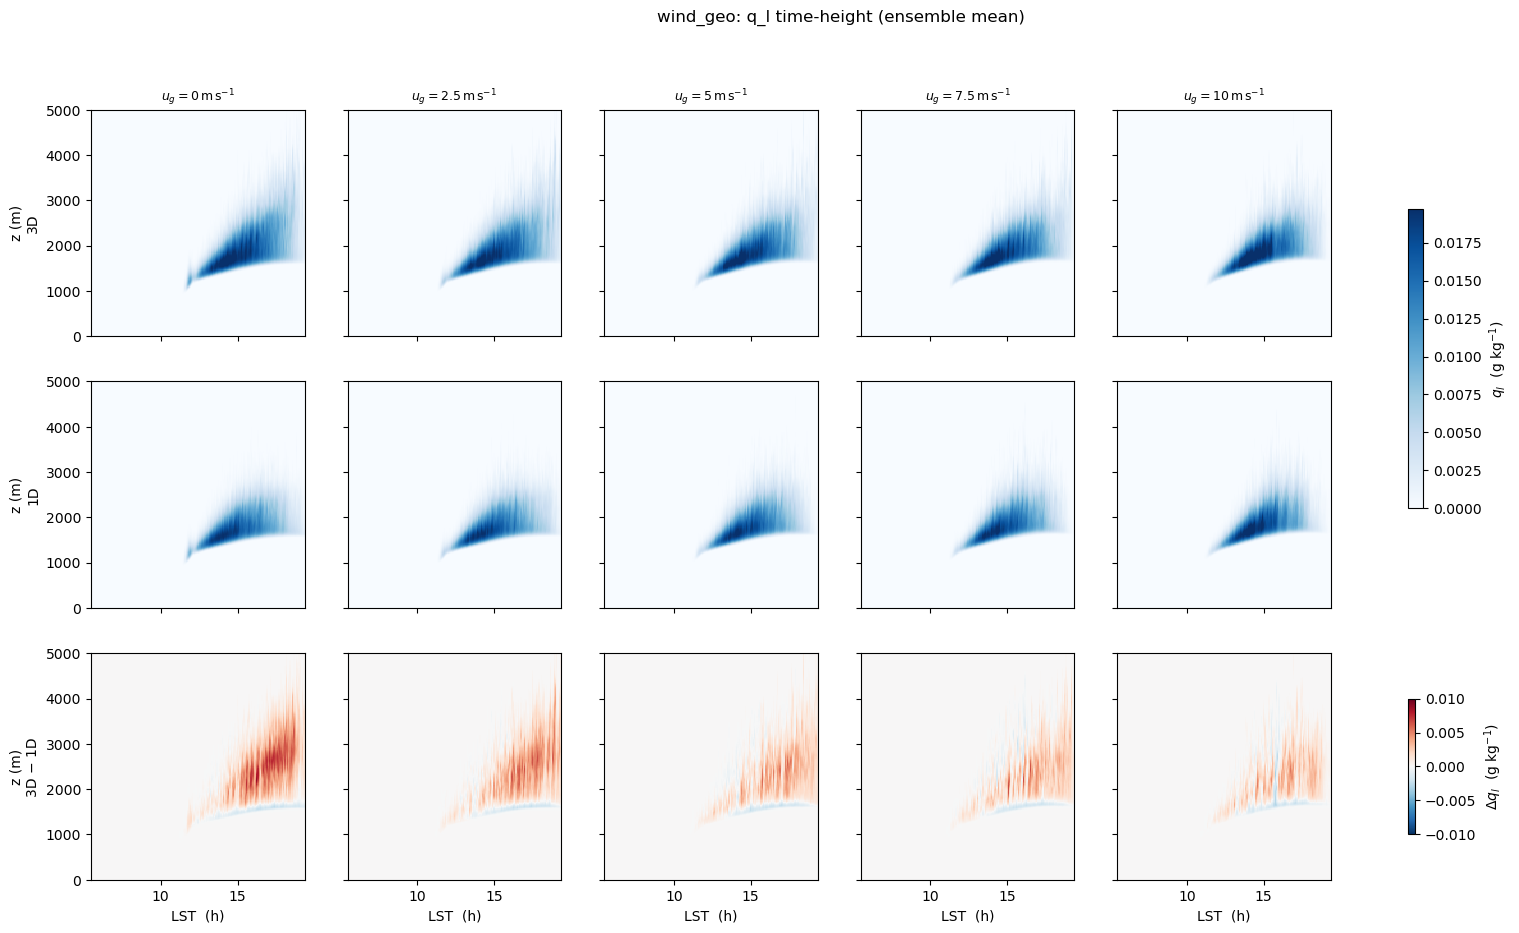

In [5]:
# ── q_l time-height cross-sections per param value ───────────────────────────
# Load thermo profiles (from cass.default.0000000.nc)
thermo = {}
for key in available:
    d = data[key]
    reps = []
    for rt_key, rep_list in [("2stream", d["reps_2s"]), ("raytracer", d["reps_rt"])]:
        if not rep_list:
            continue
        _reps_t = []
        for _s in (d["reps_rt"] if rt_key == "raytracer" else d["reps_2s"]):
            _reps_t.append({
                "t": _s["t_sec"].values,
                "z": _s.coords["z"].values,
                "ql": _s["ql"].values * 1e3,
                "thl": _s["thl"].values,
                "qt":  _s["qt"].values * 1e3,
            })
        if not _reps_t:
            continue
        nt_ = min(r["t"].shape[0] for r in _reps_t)
        avg = {"t": _reps_t[0]["t"][:nt_], "z": _reps_t[0]["z"]}
        for _k in ["ql", "thl", "qt"]:
            avg[_k] = np.stack([r[_k][:nt_] for r in _reps_t]).mean(axis=0)
        reps.append((rt_key, avg))
    thermo[key] = reps

# 3 rows: 3D (raytracer), 1D (2stream), 3D − 1D diff.
# Shared abs scale for rows 0–1; symmetric diff scale for row 2.
n_vals = len(available)
fig, axes = plt.subplots(3, n_vals, figsize=(4.0 * n_vals, 10),
                         sharey=True, sharex=True, squeeze=False)
z_max = 5000

panels = []  # (col, key, t_h, z, ql_3d, ql_1d, diff) or None for missing
for col, key in enumerate(available):
    d_2s = d_rt = None
    for rt_key, avg in thermo[key]:
        if rt_key == "2stream":
            d_2s = avg
        elif rt_key == "raytracer":
            d_rt = avg
    if d_2s is None or d_rt is None:
        panels.append(None); continue
    z    = d_2s["z"]
    zmsk = z <= z_max
    nt   = min(d_2s["ql"].shape[0], d_rt["ql"].shape[0])
    ql_3 = d_rt["ql"][:nt, zmsk]
    ql_1 = d_2s["ql"][:nt, zmsk]
    t_h  = d_rt["t"][:nt] / 3600 + LST_OFF
    panels.append((col, key, t_h, z[zmsk], ql_3, ql_1, ql_3 - ql_1))

_qabs = [p[4] for p in panels if p] + [p[5] for p in panels if p]
_qdif = [p[6] for p in panels if p]
if _qabs:
    _pos = np.concatenate([q[q > 0].ravel() for q in _qabs if (q > 0).any()]) \
            if any((q > 0).any() for q in _qabs) else np.array([0.01])
    vmax_abs  = max(float(np.nanpercentile(_pos, 99)), 0.01)
    _dif_flat = np.concatenate([np.abs(d).ravel() for d in _qdif])
    vmax_diff = max(float(np.nanpercentile(_dif_flat[np.isfinite(_dif_flat)], 99)), 0.01)
else:
    vmax_abs = vmax_diff = 0.01

pcm_abs = pcm_diff = None
for p in panels:
    if p is None:
        continue
    col, key, t_h, z_ax, ql_3, ql_1, diff = p
    pcm_abs  = axes[0, col].pcolormesh(t_h, z_ax, ql_3.T, cmap="Blues", vmin=0, vmax=vmax_abs)
    axes[1, col].pcolormesh(t_h, z_ax, ql_1.T, cmap="Blues", vmin=0, vmax=vmax_abs)
    pcm_diff = axes[2, col].pcolormesh(t_h, z_ax, diff.T, cmap="RdBu_r",
                                         vmin=-vmax_diff, vmax=vmax_diff)
    axes[0, col].set_title(LABELS[key], fontsize=9)
    axes[2, col].set_xlabel("LST  (h)")

for row, row_lbl in enumerate(["3D", "1D", "3D − 1D"]):
    axes[row, 0].set_ylabel(f"z (m)\n{row_lbl}")

if pcm_abs is not None:
    fig.colorbar(pcm_abs,  ax=axes[:2, :], location="right", shrink=0.6,
                 label=r"$q_l$  (g kg$^{-1}$)")
    fig.colorbar(pcm_diff, ax=axes[2, :],  location="right", shrink=0.6,
                 label=r"$\Delta q_l$  (g kg$^{-1}$)")
fig.suptitle(f"{SWEEP_GROUP}: q_l time-height (ensemble mean)")
_savefig(f"{SWEEP_GROUP}_ql_timeh.pdf", bbox_inches="tight")
plt.show()


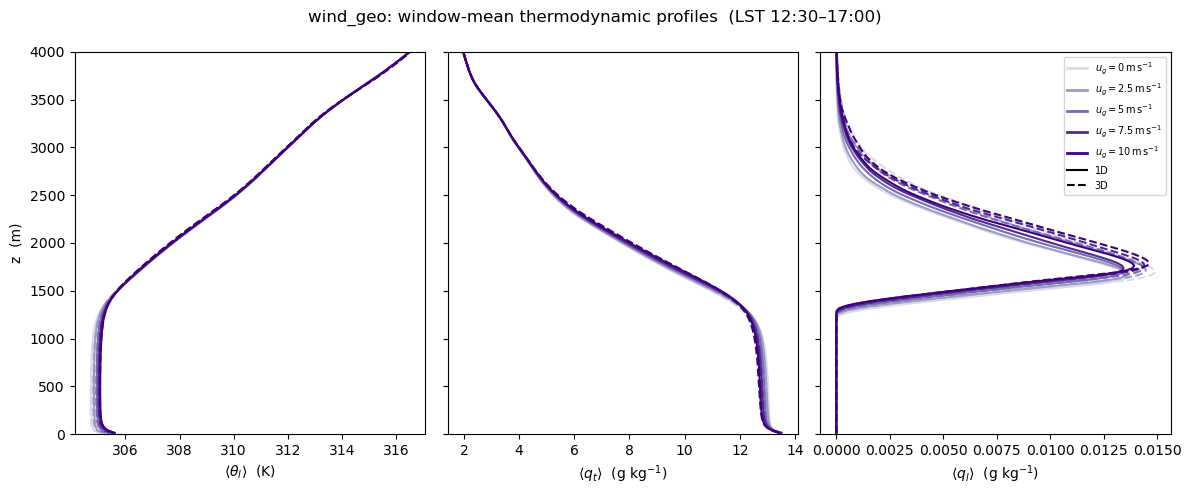

In [6]:
# ── Window-mean thermodynamic profiles ───────────────────────────────────────
import pandas as _pd
_T0 = _pd.Timestamp("2005-07-24 12:30")
_T1 = _pd.Timestamp("2005-07-24 17:00")

def _window_mean(avg_dict, key):
    t_idx = _pd.DatetimeIndex(
        _pd.to_datetime(avg_dict["t"], unit="s", origin=_pd.Timestamp("2005-07-24 05:30"))
    )
    msk = (t_idx >= _T0) & (t_idx <= _T1)
    return avg_dict[key][msk].mean(axis=0) if msk.any() else avg_dict[key].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
ax_thl, ax_qt, ax_ql = axes
z_max_p = 4000

for key in available:
    c = COLORS[key]
    for rt_key, avg in thermo[key]:
        ls = "-" if rt_key == "2stream" else "--"
        lw = 1.5
        z  = avg["z"]
        z_msk = z <= z_max_p
        ax_thl.plot(_window_mean(avg, "thl")[z_msk], z[z_msk], color=c, ls=ls, lw=lw)
        ax_qt.plot( _window_mean(avg, "qt" )[z_msk], z[z_msk], color=c, ls=ls, lw=lw)
        ax_ql.plot( _window_mean(avg, "ql" )[z_msk], z[z_msk], color=c, ls=ls, lw=lw)

ax_thl.set_xlabel(r"$\langle \theta_l \rangle$  (K)");  ax_thl.set_ylabel("z  (m)")
ax_qt.set_xlabel(r"$\langle q_t \rangle$  (g kg$^{-1}$)")
ax_ql.set_xlabel(r"$\langle q_l \rangle$  (g kg$^{-1}$)")
for ax in axes:
    ax.set_ylim(0, z_max_p)
_lh_c = [Line2D([0],[0], color=COLORS[k], lw=2, label=LABELS[k]) for k in available]
_lh_s = [Line2D([0],[0], color="k", ls="-",  lw=1.5, label="1D"),
          Line2D([0],[0], color="k", ls="--", lw=1.5, label="3D")]
ax_ql.legend(handles=_lh_c + _lh_s, fontsize=7)
fig.suptitle(f"{SWEEP_GROUP}: window-mean thermodynamic profiles  (LST 12:30–17:00)")
fig.tight_layout()
_savefig(f"{SWEEP_GROUP}_thermo_profiles.pdf", bbox_inches="tight")
plt.show()


---
## 3. Surface energy balance

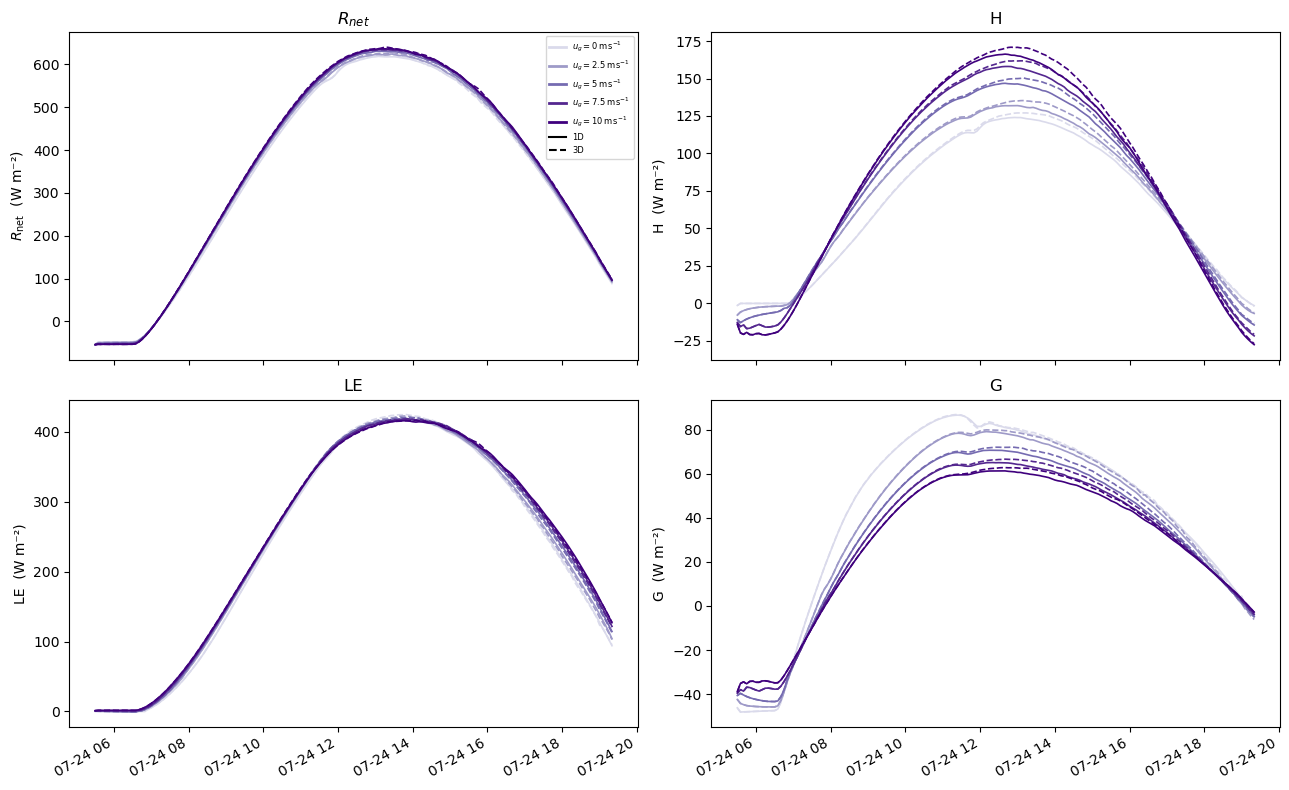

In [7]:
# ── SEB components, residual, EF ─────────────────────────────────────────────
fluxes = ["Rnet", "H", "LE", "G"]
flux_labels = {"Rnet": r"$R_\mathrm{net}$", "H": "H", "LE": "LE", "G": "G"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for key in available:
    d  = data[key]
    c  = COLORS[key]
    lbl = LABELS[key]
    for ax, flux in zip(axes.flat, fluxes):
        for rt_key, sm in [("2stream", d["s2s_mean"]), ("raytracer", d["srt_mean"])]:
            if sm is None:
                continue
            t_  = _to_plottime(sm["t_local"].values)
            ax.plot(t_, sm[flux].values,
                    color=c, ls="-" if rt_key == "2stream" else "--", lw=1.2)
        ax.set_ylabel(f"{flux_labels[flux]}  (W m⁻²)")
        ax.xaxis_date()

_lh_c = [Line2D([0],[0], color=COLORS[k], lw=2, label=LABELS[k]) for k in available]
_lh_s = [Line2D([0],[0], color="k", ls="-",  lw=1.5, label="1D"),
          Line2D([0],[0], color="k", ls="--", lw=1.5, label="3D")]
axes.flat[0].legend(handles=_lh_c + _lh_s, fontsize=6)

axes[0,0].set_title("$R_{net}$"); axes[0,1].set_title("H")
axes[1,0].set_title("LE");         axes[1,1].set_title("G")
fig.autofmt_xdate()
fig.tight_layout()
_savefig(f"{SWEEP_GROUP}_seb_components.pdf", bbox_inches="tight")
plt.show()


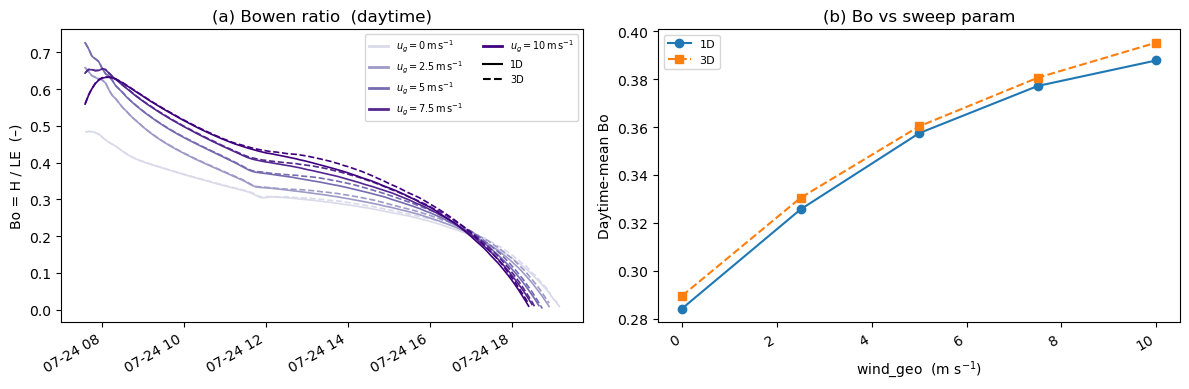

In [8]:
# ── Bowen ratio: timeseries + vs sweep param ─────────────────────────────────
fig, (ax_bo, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))

bo_1d_vals, bo_3d_vals = [], []

for key in available:
    d = data[key]
    c = COLORS[key]
    for rt_key, sm in [("2stream", d["s2s_mean"]), ("raytracer", d["srt_mean"])]:
        if sm is None:
            continue
        H   = sm["H"].values
        LE  = sm["LE"].values
        bo  = np.where(LE > 1.0, H / LE, np.nan)
        t_  = _to_plottime(sm["t_local"].values)
        day = (sm["Rnet"].values > 50) & (H > 0)
        ax_bo.plot(t_[day], bo[day], color=c,
                   ls="-" if rt_key == "2stream" else "--", lw=1.2)
        if day.any():
            bo_mean = float(np.nanmean(bo[day]))
            (bo_1d_vals if rt_key == "2stream" else bo_3d_vals).append(
                (PARAMS[key], bo_mean))

ax_bo.set_ylabel("Bo = H / LE  (–)")
ax_bo.set_title("(a) Bowen ratio  (daytime)")
_lh_c = [Line2D([0],[0], color=COLORS[k], lw=2, label=LABELS[k]) for k in available]
_lh_s = [Line2D([0],[0], color="k", ls="-",  lw=1.5, label="1D"),
          Line2D([0],[0], color="k", ls="--", lw=1.5, label="3D")]
ax_bo.legend(handles=_lh_c + _lh_s, fontsize=7, ncol=2)
ax_bo.xaxis_date()

if bo_1d_vals:
    p1d, b1d = zip(*sorted(bo_1d_vals))
    ax_bar.plot(p1d, b1d, "o-", color="C0", lw=1.5, label="1D")
if bo_3d_vals:
    p3d, b3d = zip(*sorted(bo_3d_vals))
    ax_bar.plot(p3d, b3d, "s--", color="C1", lw=1.5, label="3D")
ax_bar.set_xlabel(f"{SWEEP_GROUP}  ({PARAM_UNIT})")
ax_bar.set_ylabel("Daytime-mean Bo")
ax_bar.set_title("(b) Bo vs sweep param")
ax_bar.legend(fontsize=8)

fig.autofmt_xdate()
fig.tight_layout()
_savefig(f"{SWEEP_GROUP}_bowen_ratio.pdf", bbox_inches="tight")
plt.show()


---
## 4. Same speed, different strategy: wind_geo u=5 vs wind_sun

Both impose 5 m s⁻¹ wind. `wind_geo_5p0` = fixed-direction geostrophic;
`wind_sun` = direction tracks the solar azimuth so clouds advect toward
their own shadows. Tests whether the wind *direction strategy* changes the
3D−1D LWP enhancement beyond what wind *speed* alone does. Both are
first-class `catalog.py` entries, loaded via `make_runset`.

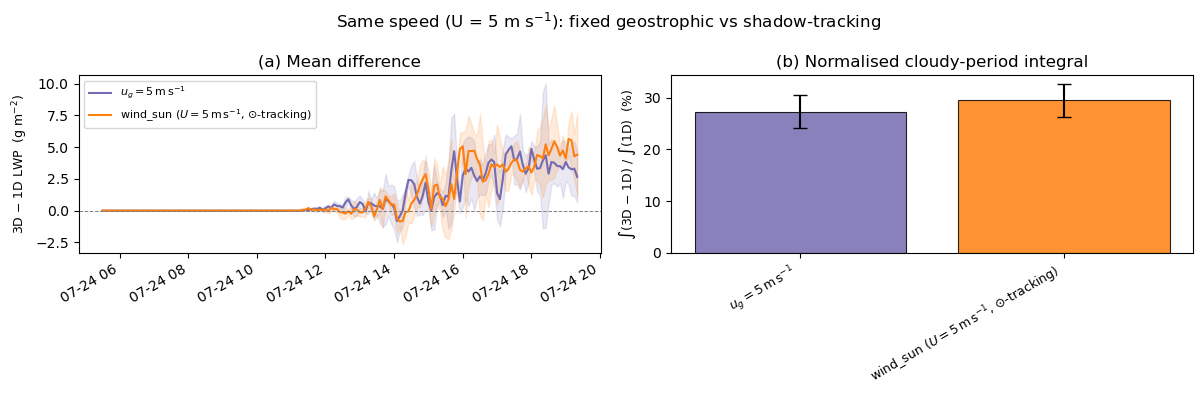

In [9]:
# ── wind_geo u=5  vs  wind_sun : same speed, fixed vs shadow-tracking ────────
# Both first-class catalog entries; loaded via make_runset like everything else.
def _lwp_pack(rs):
    """Cell-4's LWP reduction for one RunSet (2stream vs raytracer)."""
    dirs_2s, dirs_rt = rs.dirs["2stream"], rs.dirs["raytracer"]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        reps_2s = [load_stats(d) for d in dirs_2s]
        reps_rt = [load_stats(d) for d in dirs_rt]
    nt  = min(s["qlqi_path"].sizes["time"] for s in reps_2s + reps_rt)
    npr = min(len(reps_2s), len(reps_rt))
    l1  = np.stack([s["qlqi_path"].values[:nt] * 1e3 for s in reps_2s[:npr]])
    l3  = np.stack([s["qlqi_path"].values[:nt] * 1e3 for s in reps_rt[:npr]])
    dd  = l3 - l1
    diff, diff_std = dd.mean(0), dd.std(0)
    t_num = _to_plottime(reps_2s[0]["t_local"].values[:nt])
    tsec  = reps_2s[0]["t_sec"].values[:nt]
    dt_s  = float(tsec[1] - tsec[0]) if len(tsec) > 1 else 60.0
    cl    = (l1.mean(0) > 0.1) | (l3.mean(0) > 0.1)
    i1    = lwp_integral(l1.mean(0), dt_s, cloudy_mask=cl)
    ni    = lwp_integral(diff, dt_s, cloudy_mask=cl) / i1 * 100
    ni_sd = float(np.std([lwp_integral(dd[r], dt_s, cloudy_mask=cl) / i1 * 100
                          for r in range(npr)], ddof=0))
    return dict(diff=diff, diff_std=diff_std, t_num=t_num,
                norm_int=ni, norm_int_std=ni_sd)

CMP_KEYS = ["wind_geo_5p0", "wind_sun"]
cmp = {}
for k in CMP_KEYS:
    meta = ALL_EXPERIMENTS[k]
    if k in data:                       # already reduced in the sweep loop
        d = data[k]
        cmp[k] = dict(diff=d["diff"], diff_std=d["diff_std"],
                      t_num=d["t_num_lwp"], norm_int=d["norm_int"],
                      norm_int_std=d["norm_int_std"])
    else:                               # standalone catalog entry
        cmp[k] = _lwp_pack(make_runset(k, n_reps=N_REPS))
    cmp[k]["label"] = meta["label"]
    cmp[k]["color"] = meta["color"]

fig, (ax_diff, ax_int) = plt.subplots(1, 2, figsize=(12, 4))
for k in CMP_KEYS:
    d = cmp[k]
    ax_diff.plot(d["t_num"], d["diff"], color=d["color"], lw=1.5, label=d["label"])
    ax_diff.fill_between(d["t_num"], d["diff"] - d["diff_std"],
                         d["diff"] + d["diff_std"], color=d["color"], alpha=0.15)
ax_diff.axhline(0, color="gray", lw=0.7, ls="--")
ax_diff.set_ylabel(r"3D − 1D LWP  (g m$^{-2}$)", fontsize=9)
ax_diff.set_title("(a) Mean difference")
ax_diff.legend(fontsize=8)
ax_diff.xaxis_date()

x = np.arange(len(CMP_KEYS))
ax_int.bar(x, [cmp[k]["norm_int"] for k in CMP_KEYS],
           color=[cmp[k]["color"] for k in CMP_KEYS], edgecolor="k", lw=0.8,
           alpha=0.85, yerr=[cmp[k]["norm_int_std"] for k in CMP_KEYS],
           capsize=5, error_kw=dict(lw=1.5))
ax_int.axhline(0, color="gray", lw=0.7)
ax_int.set_xticks(x)
ax_int.set_xticklabels([cmp[k]["label"] for k in CMP_KEYS],
                       rotation=15, ha="right", fontsize=9)
ax_int.set_ylabel(r"$\int$(3D $-$ 1D) / $\int$(1D)  (%)", fontsize=9)
ax_int.set_title("(b) Normalised cloudy-period integral")

ax_diff.figure.autofmt_xdate()
fig.suptitle("Same speed (U = 5 m s$^{-1}$): fixed geostrophic vs shadow-tracking",
             fontsize=12)
plt.tight_layout()
_savefig("wind_geo5_vs_wind_sun_lwp.pdf", bbox_inches="tight")
plt.show()